# TalentFit — Job Data Cleaning & EDA



In [2]:
%pip install -q pandas numpy matplotlib seaborn langdetect pyarrow fuzzywuzzy python-Levenshtein requests

Note: you may need to restart the kernel to use updated packages.


In [3]:
# ============================================================
# CELL 1 – Consolidated imports for the full pipeline
# ============================================================
import re
import json
import os
import html
import unicodedata
from typing import Tuple, Optional
from pathlib import Path


import pandas as pd
import numpy as np
from fuzzywuzzy import fuzz, process
import requests                          # for local Ollama API calls

# Langdetect – for removing non‑English job descriptions
from langdetect import DetectorFactory, LangDetectException, detect
DetectorFactory.seed = 0                 # deterministic results

# Optional: plotting (if you want to visualise label distributions)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print("✅ All imports ready (langdetect, fuzzywuzzy, requests, etc.)")

✅ All imports ready (langdetect, fuzzywuzzy, requests, etc.)


In [5]:
# READ ONLY
RAW_PATH = Path('./saudi_job_market.csv')

# Output: cleaned dataset
OUT_PATH = Path('job_data_saudi_clean.csv')

assert RAW_PATH.resolve() != OUT_PATH.resolve(), \
    'RAW_PATH and OUT_PATH must point to different files'


print(f'Reading from : {RAW_PATH.resolve()}  ({RAW_PATH.stat().st_size / 1024 / 1024:.1f} MB)')
print(f'Will write to: {OUT_PATH.resolve()}')

Reading from : C:\Users\yazze\Desktop\Job Market Intelligence AI\saudi_job_market.csv  (595.2 MB)
Will write to: C:\Users\yazze\Desktop\Job Market Intelligence AI\job_data_saudi_clean.csv


In [7]:
# Raw column name -> friendly name (project schema)
COLUMN_MAP = {
    'jobid':                                'job_id',
    'job_title':                            'job_title',
    'description_text':                     'job_description',
    'company_name':                         'company',
    'job_location':                         'location_raw',
    'salary_formatted':                     'salary',
    'input_discovery_input_keyword_search': 'search_query',
    'date_posted_parsed':                   'date_posted',
    'company_rating':                       'company_rating',
    'is_expired':                           'is_expired',
    'url':                                  'url',
}

# Arabic city -> English city
LOCATION_AR_TO_EN = {
    'الرياض': 'Riyadh',          'جدة': 'Jeddah',
    'الخبر': 'Al Khobar',        'الدمام': 'Dammam',
    'الظهران': 'Dhahran',        'مكة المكرمة': 'Mecca',
    'مكة': 'Mecca',              'المدينة المنورة': 'Medina',
    'المدينة': 'Medina',          'تبوك': 'Tabuk',
    'الجبيل': 'Jubail',           'ينبع': 'Yanbu',
    'ينبع البحر': 'Yanbu',        'أبها': 'Abha',
    'الطائف': 'Taif',             'حائل': 'Hail',
    'نجران': 'Najran',            'جازان': 'Jazan',
    'الأحساء': 'Al Ahsa',         'بريدة': 'Buraidah',
    'الهفوف': 'Hofuf',            'ثول': 'Thuwal',
    'الخرج': 'Al Kharj',          'منطقة الشرقية': 'Eastern Province',
    'بقيق': 'Abqaiq',             'رأس الخير': 'Ras Al-Khair',
    'المملكة العربية السعودية':   'Saudi Arabia',
}

KNOWN_CITIES = [
    'Riyadh', 'Jeddah', 'Al Khobar', 'Khobar', 'Dammam', 'Dhahran',
    'Mecca', 'Medina', 'Tabuk', 'Jubail', 'Yanbu', 'Abha', 'Taif',
    'Hail', 'Najran', 'Jazan', 'Al Ahsa', 'Buraidah', 'Hofuf', 'Thuwal',
    'Al Kharj', 'Ras Al-Khair', 'Abqaiq',
]

MIN_DESC_LEN  = 200
MIN_TITLE_LEN = 6

print('Tables loaded.')

Tables loaded.


In [7]:
# Tech category rules. (label, regex). First match wins.

"""
TECH_CATEGORY_RULES = [
    ('ML Engineer',        r'\b(machine learning|ml engineer|mlops|computer vision|nlp engineer)\b'),
    ('AI Engineer',        r'\b(ai engineer|ai/ml|generative ai|\bllm\b|prompt engineer|deep learning|ai specialist|ai consultant)\b'),
    ('Data Scientist',     r'\b(data scientist|applied scientist|research scientist)\b'),
    ('Data Engineer',      r'\b(data engineer|etl developer|big data|data platform|data pipeline|data warehouse engineer)\b'),
    ('Data Analyst',       r'\b(data analyst|bi developer|business intelligence|power bi|tableau|reporting analyst|data quality|data governance|data steward|analytics engineer)\b'),
    ('DevOps/Cloud',       r'\b(devops|sre\b|site reliability|cloud engineer|platform engineer|aws engineer|azure engineer|gcp engineer|kubernetes|infrastructure engineer|cloud architect|cloud solutions architect|cloud security|network engineer|systems engineer|linux engineer|cloud consultant)\b'),
    ('Cybersecurity',      r'\b(cyber\s*security|infosec|security engineer|security analyst|soc analyst|penetration test|pentest|vapt|\biam\b|\bpam\b|application security)\b'),
    ('Mobile Developer',   r'\b(mobile (developer|engineer)|ios developer|android developer|flutter developer|react native)\b'),
    ('Frontend Developer', r'\b(front[- ]?end|web developer|react developer|angular developer|ui developer|ux engineer)\b'),
    ('Backend Developer',  r'\b(back[- ]?end|api developer|node\.?js developer|java developer|python developer|golang developer|\.net developer|php developer)\b'),
    ('Full Stack',         r'\b(full[- ]?stack)\b'),
    ('Software Engineer',  r'\b(software engineer(?:ing)?|software developer|software development|programmer|coder)\b'),
    ('IT Support',         r'\b(it support|it specialist|help desk|service desk|desktop support|system administrator|sysadmin|database administrator|dba\b)\b'),
]

TECH_ARCHITECT_RE = re.compile(
    r'\b(software architect|solutions? architect|cloud architect|data architect|'
    r'enterprise architect|technical architect|systems architect|security architect|'
    r'ai architect|ml architect|application architect)\b',
    re.IGNORECASE,
)

# Non-tech category rules. Same shape as tech.
NON_TECH_CATEGORY_RULES = [
    ('Non-Tech: Healthcare',
     r'\b(nurse|doctor|physician|pharmacist|dentist|surgeon|medical|paramedic|radiologist|nutritionist|therapist|psychologist|veterinarian|midwife)\b'),
    ('Non-Tech: Construction',
     r'\b(construction|site engineer|site manager|foreman|inspector|surveyor|bim manager|estimator|estimation manager|quantity surveyor|land surveyor|hse engineer|hse manager|safety officer|safety engineer|planning engineer|project controls|cost engineer|cost control engineer|architectural engineer|interior designer)\b'),
    ('Non-Tech: Engineering',
     r'\b(civil engineer|mechanical engineer|electrical engineer|structural engineer|process engineer|piping engineer|hvac engineer|chemical engineer|materials engineer|reservoir engineer|drilling engineer|petroleum engineer|industrial engineer|aerospace engineer|automotive engineer|environmental engineer|geotechnical engineer|metallurgical engineer|telecommunications engineer|biomedical engineer|electrical design engineer|qa/qc engineer|quality engineer|electronic engineer|nuclear engineer)\b'),
    ('Non-Tech: Sales/BD',
     r'\b(sales|account executive|account manager|business development|customer success|key account|sales engineer|sales manager|channel manager|partner manager)\b'),
    ('Non-Tech: Marketing',
     r'\b(marketing|brand manager|content writer|copywriter|digital marketing|seo specialist|social media|public relations|communications manager|growth manager|product marketing)\b'),
    ('Non-Tech: Finance',
     r'\b(finance|accountant|treasury|audit|financial analyst|payroll|bookkeeper|controller|cfo\b|tax(?!onomy) manager|risk analyst)\b'),
    ('Non-Tech: HR',
     r'\b(human resources|recruiter|talent acquisition|hr |chief people|learning and development|compensation|benefits|hr manager|hr business partner)\b'),
    ('Non-Tech: Supply Chain',
     r'\b(procurement|purchasing|supply chain|logistics|warehouse|inventory|materials management|expeditor|shipping)\b'),
    ('Non-Tech: Operations',
     r'\b(operations manager|operations director|general manager|office manager|administrative|admin|project manager|program manager|pmo|project director|project coordinator|business analyst|document controller|executive assistant|secretary)\b'),
]

print(f'{len(TECH_CATEGORY_RULES)} tech rules + {len(NON_TECH_CATEGORY_RULES)} non-tech rules loaded.') 

MIGHT USE AFTER LLM LABELLING


"""

"\nTECH_CATEGORY_RULES = [\n    ('ML Engineer',        r'\x08(machine learning|ml engineer|mlops|computer vision|nlp engineer)\x08'),\n    ('AI Engineer',        r'\x08(ai engineer|ai/ml|generative ai|\x08llm\x08|prompt engineer|deep learning|ai specialist|ai consultant)\x08'),\n    ('Data Scientist',     r'\x08(data scientist|applied scientist|research scientist)\x08'),\n    ('Data Engineer',      r'\x08(data engineer|etl developer|big data|data platform|data pipeline|data warehouse engineer)\x08'),\n    ('Data Analyst',       r'\x08(data analyst|bi developer|business intelligence|power bi|tableau|reporting analyst|data quality|data governance|data steward|analytics engineer)\x08'),\n    ('DevOps/Cloud',       r'\x08(devops|sre\x08|site reliability|cloud engineer|platform engineer|aws engineer|azure engineer|gcp engineer|kubernetes|infrastructure engineer|cloud architect|cloud solutions architect|cloud security|network engineer|systems engineer|linux engineer|cloud consultant)\x08'),\

## 2. Helper functions
utilities for cleaning text, normalizing locations, and assigning categories.

In [8]:
HTML_TAG_RE   = re.compile(r'<[^>]+>')
WHITESPACE_RE = re.compile(r'\s+')
URL_RE        = re.compile(r'https?://\S+')
ARABIC_CHAR_RE = re.compile(r'[\u0600-\u06FF]+')
LOC_TRAILING_AR_SUFFIX_RE = re.compile(r'\s+in\s+[\u0600-\u06FF\s]+$', re.IGNORECASE)


def clean_text(value):
    """Decode HTML entities, strip tags/URLs, normalize whitespace + unicode."""
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return None
    text = str(value)
    text = html.unescape(html.unescape(text))            # &amp;amp; -> &
    text = unicodedata.normalize('NFKC', text)            # smart quotes etc.
    text = HTML_TAG_RE.sub(' ', text)                     # <br>, <p>
    text = URL_RE.sub(' ', text)
    text = text.replace('\u200b', ' ').replace('\xa0', ' ')
    text = WHITESPACE_RE.sub(' ', text).strip()
    return text or None


def clean_salary(value):
    """Junk salary values become NaN; real strings kept."""
    text = clean_text(value)
    if text is None or text in ('[]', '{}', 'null', 'None', '-'):
        return None
    return text


def normalize_location(value):
    """Map Arabic city names to English, extract city from address strings."""
    text = clean_text(value)
    if text is None:
        return None
    if text in LOCATION_AR_TO_EN:
        return LOCATION_AR_TO_EN[text]
    m = LOC_TRAILING_AR_SUFFIX_RE.search(text)
    if m:
        ar_part = m.group(0).split('in', 1)[1].strip()
        if ar_part in LOCATION_AR_TO_EN:
            return LOCATION_AR_TO_EN[ar_part]
        first_ar = ARABIC_CHAR_RE.search(ar_part)
        if first_ar and first_ar.group(0) in LOCATION_AR_TO_EN:
            return LOCATION_AR_TO_EN[first_ar.group(0)]
    head = text.split(',')[0].strip()
    if head in LOCATION_AR_TO_EN:
        return LOCATION_AR_TO_EN[head]
    for city in KNOWN_CITIES:
        if re.search(rf'\b{re.escape(city)}\b', text, re.IGNORECASE):
            return city
    if head and not ARABIC_CHAR_RE.search(head):
        return head if len(head) <= 40 else 'Saudi Arabia'
    if ARABIC_CHAR_RE.search(text):
        return 'Saudi Arabia'
    return text

'''
def assign_category(job_title):
    """14 tech categories + 9 specific non-tech + 'Non-Tech: Other'."""
    if not job_title or pd.isna(job_title):
        return 'Non-Tech: Other'
    title = str(job_title).lower()
    if TECH_ARCHITECT_RE.search(title):
        return 'Solutions Architect'
    for label, pattern in TECH_CATEGORY_RULES:
        if re.search(pattern, title, re.IGNORECASE):
            return label
    if re.search(r'\b(developer|programmer|coder)\b', title, re.IGNORECASE):
        return 'Software Engineer'
    for label, pattern in NON_TECH_CATEGORY_RULES:
        if re.search(pattern, title, re.IGNORECASE):
            return label
    return 'Non-Tech: Other'
'''

def safe_detect_lang(text):
    if not text or len(text) < 20:
        return 'unknown'
    try:
        return detect(text[:1500])
    except LangDetectException:
        return 'unknown'


print('Helpers ready.')

Helpers ready.


## 3. Cleaning

### STEP 1 — Load the raw CSV

In [9]:
df = pd.read_csv(RAW_PATH, low_memory=False, usecols=list(COLUMN_MAP.keys()))
df = df.rename(columns=COLUMN_MAP)
print(f'Loaded {len(df):,} rows, {len(df.columns)} columns')
df.head()

Loaded 46,919 rows, 11 columns


,job_id,company,date_posted,job_title,job_description,salary,company_rating,url,is_expired,location_raw,search_query
0,32ecfd63823c0691,DXC Technology,2025-07-02 16:17:30.595000+00:00,Lead Storage Backup Engineer,Job Description: Essential Job Functions: ...,NaN,3.2,https://sa.indeed.com/viewjob?jk=32ecfd63823c0691,False,الرياض,cloud engineer
1,cbda9008da66fbe2,TAM Development Co.,2025-06-30 13:01:15.774000+00:00,Software Engineer,"TAM is a Saudi publicly listed company, specia...",NaN,NaN,https://sa.indeed.com/viewjob?jk=cbda9008da66fbe2,False,الرياض,cloud engineer
2,7623b2d1848b53b6,DXC Technology,2025-07-02 16:17:27.544000+00:00,Senior Storage Backup Engineer,Job Description: Responsibilities: St...,NaN,3.2,https://sa.indeed.com/viewjob?jk=7623b2d1848b53b6,False,الرياض,cloud security engineer
3,0728eeb152762255,Microsoft,2025-06-30 14:45:22.945000+00:00,Critical Environment Field Service Engineer,Business Function Overview: In alignment ...,NaN,4.2,https://sa.indeed.com/viewjob?jk=0728eeb152762255,False,الدمام,cloud security engineer
4,f2ad4ea17dd2c1c1,SWATX,2025-07-01 10:02:12.261000+00:00,L3 Network Security Engineer,"As an L3 Network Security Engineer at SWATX, y...",NaN,NaN,https://sa.indeed.com/viewjob?jk=f2ad4ea17dd2c1c1,False,Riyadh,cloud security engineer


### STEP 3 — Drop rows missing critical fields or with junk content
Rules:
- Must have `job_id`, `job_title`, and `job_description`.
- Description must be at least 200 characters.
- Title must be at least 6 characters (rejects like `Co`, `PMO`, `ISR`).

In [10]:
before = len(df)
df = df.dropna(subset=['job_id', 'job_title', 'job_description']).copy()
df = df[df['job_description'].str.len() >= MIN_DESC_LEN]
df = df[df['job_title'].str.len() >= MIN_TITLE_LEN]
print(f'Dropped: {before - len(df):,}   Remaining: {len(df):,}')

Dropped: 445   Remaining: 46,474


### STEP 4 — Clean text fields
Apply `clean_text` to title, description, company, and salary. Then re-check lengths.

In [11]:
df['job_title']       = df['job_title'].map(clean_text)
df['job_description'] = df['job_description'].map(clean_text)
df['company']         = df['company'].map(clean_text)
df['salary']          = df['salary'].map(clean_salary)
before = len(df)
df = df[df['job_title'].str.len() >= MIN_TITLE_LEN]
df = df[df['job_description'].str.len() >= MIN_DESC_LEN]
print(f'Dropped after re-check: {before - len(df):,}   Remaining: {len(df):,}')

Dropped after re-check: 0   Remaining: 46,474


### STEP 5 — Deduplicate
Two passes:
1. **Exact duplicates** by `job_id` (scraper hit the same listing on multiple days).
2. **Reposted jobs** — same `(title, company, first 200 chars of description)` under different IDs.

We keep the **most recent** posting in each group.

In [12]:
before = len(df)
df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce', utc=True)
df = df.sort_values('date_posted', ascending=False)

# Pass (a): exact duplicates
df = df.drop_duplicates(subset=['job_id'], keep='first')
after_id = len(df)
print(f'Dropped by job_id:                       {before - after_id:>7,}')

# Pass (b): reposted under a new ID
df['_desc_head'] = df['job_description'].str.slice(0, 200)
df = df.drop_duplicates(subset=['job_title', 'company', '_desc_head'], keep='first')
df = df.drop(columns=['_desc_head'])
print(f'Dropped by (title, company, desc-head):  {after_id - len(df):>7,}')
print(f'Remaining: {len(df):,}')

Dropped by job_id:                        31,276
Dropped by (title, company, desc-head):    1,219
Remaining: 13,979


### STEP 6 — Normalize locations (Arabic → English)
Map Arabic city names to English and extract cities from address strings like `'Prince Abdulaziz Ibn Musaid St, Riyadh, Saudi Arabia'`.

In [13]:
df['location'] = df['location_raw'].map(normalize_location)
df = df.drop(columns=['location_raw'])
print(f"Unique locations after cleanup: {df['location'].nunique()}")
df['location'].value_counts()

Unique locations after cleanup: 58


location
Riyadh                                8658
Saudi Arabia                          1464
Jeddah                                 916
Al Khobar                              826
Dammam                                 643
Tabuk                                  260
Dhahran                                245
Jubail                                 225
Medina                                 106
Yanbu                                   83
Mecca                                   78
Thuwal                                  45
Ras Al-Khair                            44
Jizan                                   43
Abha                                    33
Jazan                                   29
Taif                                    24
Ta'if                                   24
Eastern Province                        23
Duba                                    21
Jīzan                                   21
Al-Kharj                                15
Abqaiq                                  14
Al

### STEP 7 — Assign category (14 tech + 10 non-tech)
Match each title against the rules. Adds an `is_tech` boolean for easy filtering.

In [ ]:
'''
df['seed_category'] = df['job_title'].map(assign_category)
df['is_tech']       = ~df['seed_category'].str.startswith('Non-Tech')

print(f"Tech: {df['is_tech'].sum():,}  |  Non-tech: {(~df['is_tech']).sum():,}\n")
df['seed_category'].value_counts()
'''

### STEP 8 — Detect description language
Uses `langdetect`. Takes about a minute on the full dataset.

In [ ]:
df['lang'] = df['job_description'].map(safe_detect_lang)
df['lang'].value_counts()

### STEP 9 — Keep only English descriptions
Our category names are English.

In [ ]:
before = len(df)
df = df[df['lang'] == 'en'].copy()
print(f'Dropped non-English: {before - len(df):,}   Remaining: {len(df):,}')

### STEP 10 — Final schema + save

In [ ]:
df['description_length'] = df['job_description'].str.len()
#df['industry']           = df['is_tech'].map({True: 'Technology', False: 'Non-Technology'})

FINAL_COLS = [
    'job_id', 'job_title', 'job_description', 'company', 'location',
    'salary',
    'search_query', 'lang', 'description_length',
    'date_posted', 'company_rating', 'url',
]
df = df[FINAL_COLS].reset_index(drop=True)

OUT_CSV = 'job_data_saudi_clean.csv'
df.to_csv(OUT_CSV, index=False, encoding='utf-8')
print(f'Saved {OUT_CSV}: {len(df):,} rows, {len(df.columns)} columns')
df.head()

In [ ]:
# Confirm where the file landed on disk
out_path = Path(OUT_CSV).resolve()
print(f'Cleaned dataset saved to:\n  {out_path}')
print(f'Size: {out_path.stat().st_size / 1024 / 1024:.1f} MB')

---
# 4. Exploratory Data Analysis

for cleaned dataset.

In [ ]:
df['description_length'] = df['job_description'].str.len()
df['industry']           = df['is_tech'].map({True: 'Technology', False: 'Non-Technology'})

FINAL_COLS = [
    'job_id', 'job_title', 'job_description', 'company', 'location',
    'salary', 'industry', 'seed_category', 'is_tech',
    'search_query', 'lang', 'description_length',
    'date_posted', 'company_rating', 'url',
]
df = df[FINAL_COLS].reset_index(drop=True)

# Write to OUT_PATH (defined at the top of the notebook).
# The raw CSV at RAW_PATH is NOT touched.
df.to_csv(OUT_PATH, index=False, encoding='utf-8')
print(f'Saved {OUT_PATH.name}: {len(df):,} rows, {len(df.columns)} columns')
df.head()

In [ ]:
# Confirm where the cleaned file landed, and that the raw file is untouched
print(f'Cleaned file written to:')
print(f'  {OUT_PATH.resolve()}')
print(f'  Size: {OUT_PATH.stat().st_size / 1024 / 1024:.1f} MB\n')

print(f'Raw file (untouched):')
print(f'  {RAW_PATH.resolve()}')
print(f'  Size: {RAW_PATH.stat().st_size / 1024 / 1024:.1f} MB')

### 4.1 — Tech vs Non-Tech split (pie)

In [ ]:
split_counts = df['is_tech'].value_counts().rename({True: 'Tech', False: 'Non-Tech'})

fig, ax = plt.subplots(figsize=(7, 7))
colors = ['#5A9BD4', '#E8A87C']
ax.pie(
    split_counts.values,
    labels=[f'{lab}\n{n:,} ({100*n/len(df):.1f}%)' for lab, n in split_counts.items()],
    colors=colors,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 13},
)
ax.set_title('Tech vs Non-Tech Jobs', fontsize=15, pad=15)
plt.tight_layout(); plt.show()

### 4.2 — All 24 categories (horizontal bar)

In [ ]:
cat_counts = df['seed_category'].value_counts()
is_tech_cat = ~cat_counts.index.str.startswith('Non-Tech')
colors = ['#5A9BD4' if t else '#E8A87C' for t in is_tech_cat]

fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(cat_counts.index[::-1], cat_counts.values[::-1], color=colors[::-1])
ax.set_xlabel('Number of job postings')
ax.set_title('Job postings by category (blue = tech, orange = non-tech)', fontsize=14, pad=12)
for i, v in enumerate(cat_counts.values[::-1]):
    ax.text(v + 80, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### 4.3 — Tech category breakdown (donut chart)

In [ ]:
tech_counts = df[df['is_tech']]['seed_category'].value_counts()

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    tech_counts.values,
    labels=tech_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.78,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.42},
    textprops={'fontsize': 10},
    colors=sns.color_palette('crest', n_colors=len(tech_counts)),
)
for at in autotexts: at.set_fontsize(9); at.set_color('white')
ax.set_title(f'Tech jobs by category ({tech_counts.sum():,} total)', fontsize=14, pad=15)
plt.tight_layout(); plt.show()

### 4.4 — Non-Tech category breakdown (donut chart)

In [ ]:
non_tech_counts = df[~df['is_tech']]['seed_category'].value_counts()
labels = [c.replace('Non-Tech: ', '') for c in non_tech_counts.index]

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    non_tech_counts.values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.78,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2, 'width': 0.42},
    textprops={'fontsize': 10},
    colors=sns.color_palette('flare', n_colors=len(non_tech_counts)),
)
for at in autotexts: at.set_fontsize(9); at.set_color('white')
ax.set_title(f'Non-tech jobs by category ({non_tech_counts.sum():,} total)', fontsize=14, pad=15)
plt.tight_layout(); plt.show()

### 4.5 — Top 15 hiring companies

In [ ]:
top_companies = df['company'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_companies.index[::-1], top_companies.values[::-1], color='#4A6FA5')
ax.set_xlabel('Number of job postings')
ax.set_title('Top 15 hiring companies (KSA)', fontsize=14, pad=12)
for i, v in enumerate(top_companies.values[::-1]):
    ax.text(v + 5, i, f'{v:,}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

### 4.6 — Top 10 cities (bar + pie side by side)

In [ ]:
top_loc = df['location'].value_counts().head(10)
other_count = df['location'].value_counts().iloc[10:].sum()
loc_for_pie = pd.concat([top_loc, pd.Series({'Other': other_count})])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# Bar (left)
ax1.barh(top_loc.index[::-1], top_loc.values[::-1], color='#5C8A5C')
ax1.set_xlabel('Number of postings')
ax1.set_title('Top 10 cities — counts', fontsize=13, pad=10)
for i, v in enumerate(top_loc.values[::-1]):
    ax1.text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# Pie (right)
ax2.pie(
    loc_for_pie.values, labels=loc_for_pie.index,
    autopct='%1.1f%%', startangle=90, pctdistance=0.78,
    colors=sns.color_palette('YlGnBu', n_colors=len(loc_for_pie)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 10},
)
ax2.set_title('Top 10 cities — share', fontsize=13, pad=10)
plt.tight_layout(); plt.show()

### 4.7 — Description length distribution

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(df['description_length'], bins=60, color='#7E57C2', edgecolor='white')
ax.axvline(df['description_length'].median(), color='red', linestyle='--',
           label=f"median = {df['description_length'].median():,.0f} chars")
ax.set_xlabel('Description length (characters)')
ax.set_ylabel('Number of jobs')
ax.set_title('Distribution of job-description length', fontsize=13, pad=10)
ax.legend()
plt.tight_layout(); plt.show()

### 4.8 — Salary disclosure rate

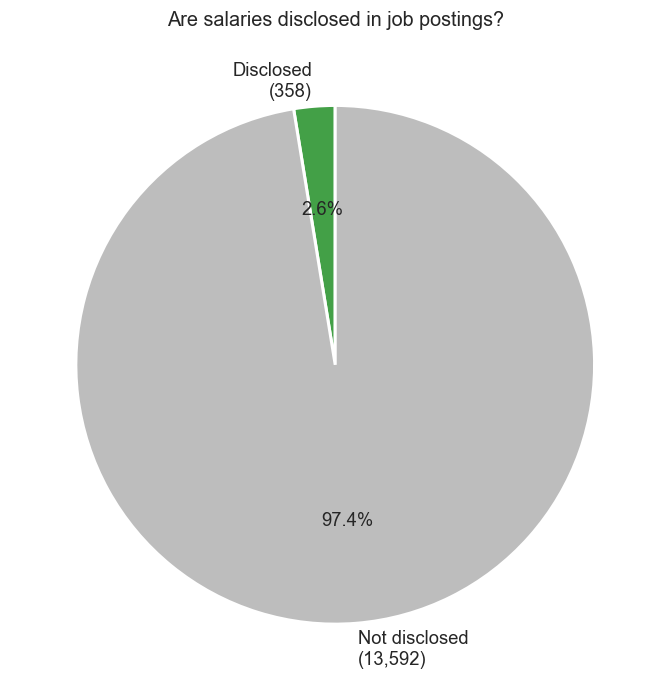

In [18]:
has_salary = df['salary'].notna()
labels = [f'Disclosed\n({has_salary.sum():,})', f'Not disclosed\n({(~has_salary).sum():,})']
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.pie(
    [has_salary.sum(), (~has_salary).sum()],
    labels=labels,
    autopct='%1.1f%%', startangle=90,
    colors=['#43A047', '#BDBDBD'],
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12},
)
ax.set_title('Are salaries disclosed in job postings?', fontsize=13, pad=10)
plt.tight_layout(); plt.show()

### 4.9 — Postings over time

In [ ]:
ts = df.dropna(subset=['date_posted']).set_index('date_posted')
monthly = ts.resample('W')['job_id'].count()  # weekly bucket

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly.index, monthly.values, marker='o', color='#1E88E5', linewidth=2)
ax.fill_between(monthly.index, monthly.values, alpha=0.2, color='#1E88E5')
ax.set_xlabel('Week')
ax.set_ylabel('Postings (per week)')
ax.set_title('Job postings over time', fontsize=13, pad=10)
plt.tight_layout(); plt.show()

### 4.10 — Category × City heatmap (top categories × top cities)

In [ ]:
top_cats = df['seed_category'].value_counts().head(12).index
top_locs = df['location'].value_counts().head(8).index

pivot = (
    df[df['seed_category'].isin(top_cats) & df['location'].isin(top_locs)]
    .pivot_table(index='seed_category', columns='location', values='job_id', aggfunc='count', fill_value=0)
    .reindex(index=top_cats, columns=top_locs)
)

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu', linewidths=0.5,
            cbar_kws={'label': 'Postings'}, ax=ax)
ax.set_title('Top categories × top cities — job postings count', fontsize=13, pad=12)
ax.set_xlabel('City')
ax.set_ylabel('Category')
plt.tight_layout(); plt.show()

### 4.11 — A sample tech and non-tech row

In [ ]:
print('--- Sample TECH job ---')
tech_sample = df[df['is_tech']].sample(1, random_state=42).iloc[0]
for col in ['job_id', 'job_title', 'company', 'location', 'seed_category', 'salary']:
    print(f'  {col:<15}: {tech_sample[col]}')
print(f'  description (first 280 chars):\n  {tech_sample["job_description"][:280]}...')

print('\n--- Sample NON-TECH job ---')
non_tech_sample = df[~df['is_tech']].sample(1, random_state=42).iloc[0]
for col in ['job_id', 'job_title', 'company', 'location', 'seed_category', 'salary']:
    print(f'  {col:<15}: {non_tech_sample[col]}')
print(f'  description (first 280 chars):\n  {non_tech_sample["job_description"][:280]}...')

## Done

